# Perturbation-detection experiment: outcomes

Scores every run under `outs/` against its matching ground-truth dataset at the repo root (`NFINITE100*`), using the same `load_predictions`/`per_class_metrics` pipeline as `src/evaluate_models.py` -- so numbers here always match the CLI.

The experiment sweeps two things:
- **model**: `qwen32_instruct` vs `qwen8_instruct`
- **render pass**: the reference/perturbed images are rendered under `regular` (full PBR) plus 7 alternate passes (`flat_albedo`, `depth`, `normal`, `ao_only`, `instance_segmentation`, `wireframe`, `matcap`) that strip away different amounts of visual information -- see `render_all_passes.sh`.

This lets us ask: which perturbation types does each model actually struggle with, and does stripping color/material/lighting information help or hurt detecting them?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from src.evaluate_models import PERTURBATION_CLASSES, load_predictions, per_class_metrics

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTS_DIR = REPO_ROOT / "outs"

# Fixed display order (not alphabetical) so every table/chart reads the same way.
MODEL_ORDER = ["qwen32_instruct", "qwen8_instruct"]
PASS_ORDER = [
    "regular",
    "flat_albedo",
    "depth",
    "normal",
    "ao_only",
    "instance_segmentation",
    # "wireframe",
    # "matcap",
]
CLASS_ORDER = ["count", "scale", "rotation", "placement", "none"]

# Validated categorical palette (blue / orange) -- kept consistent for each model
# across every chart in this notebook so color always means the same thing.
MODEL_COLOR = {"qwen32_instruct": "#2a78d6", "qwen8_instruct": "#eb6834"}
SEQUENTIAL_CMAP = "Blues"
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging", ["#eb6834", "#e8e6e0", "#2a78d6"])

## Discover experiments and load predictions

Every `outs/NFINITE100*` directory is one render pass; `outs/NFINITE100` itself is `regular`. Each is scored against the dataset of the same name at the repo root (`NFINITE100*`), which holds the matching ground truth (`perturbations.json`).

In [2]:
def pass_name(dataset_dirname: str) -> str:
    prefix = "NFINITE100"
    return "regular" if dataset_dirname == prefix else dataset_dirname[len(prefix) + 1 :]


experiment_dirs = sorted(p for p in OUTS_DIR.glob("NFINITE100*") if p.is_dir())

all_predictions = []
for output_dir in experiment_dirs:
    dataset_dir = REPO_ROOT / output_dir.name
    if not dataset_dir.is_dir():
        print(f"skipping {output_dir.name}: no matching dataset at {dataset_dir}")
        continue

    predictions_df = load_predictions(output_dir, dataset_dir)
    predictions_df["pass"] = pass_name(output_dir.name)
    all_predictions.append(predictions_df)

all_predictions = pd.concat(all_predictions, ignore_index=True)
all_predictions["pass"] = pd.Categorical(all_predictions["pass"], categories=PASS_ORDER, ordered=True)
all_predictions["model"] = pd.Categorical(all_predictions["model"], categories=MODEL_ORDER, ordered=True)

print(f"{len(all_predictions)} scored predictions across {all_predictions['pass'].nunique()} passes x {all_predictions['model'].nunique()} models")
all_predictions.groupby(["pass", "model"], observed=True).size().unstack("model")

13554 scored predictions across 6 passes x 2 models


/tmp/ipykernel_1887879/2036111834.py:20: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  all_predictions["pass"] = pd.Categorical(all_predictions["pass"], categories=PASS_ORDER, ordered=True)
/tmp/ipykernel_1887879/2036111834.py:21: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  all_predictions["model"] = pd.Categorical(all_predictions["model"], categories=MODEL_ORDER, ordered=True)


model,qwen32_instruct,qwen8_instruct
pass,,
regular,640,639
flat_albedo,640,627
depth,640,636
normal,640,639
ao_only,640,634
instance_segmentation,640,640


## Per-class metrics for every (pass, model)

`per_class_metrics` (from `src/evaluate_models.py`) computes one-vs-rest accuracy/precision/recall/F1/AUROC per class within a single predictions table; this runs it once per render pass and stacks the results with a `pass` column.

In [3]:
all_metrics = []
for pass_, group in all_predictions.groupby("pass", observed=True):
    metrics = per_class_metrics(group).reset_index()
    metrics["pass"] = pass_
    all_metrics.append(metrics)

all_metrics = pd.concat(all_metrics, ignore_index=True)
all_metrics["pass"] = pd.Categorical(all_metrics["pass"], categories=PASS_ORDER, ordered=True)
all_metrics["model"] = pd.Categorical(all_metrics["model"], categories=MODEL_ORDER, ordered=True)
all_metrics["class"] = pd.Categorical(all_metrics["class"], categories=CLASS_ORDER, ordered=True)

all_metrics.round(3)

,model,class,support,accuracy,precision,recall,f1,balanced_accuracy,pass
0,qwen32_instruct,count,39,0.955,0.604,0.744,0.667,0.856,regular
1,qwen32_instruct,none,483,0.830,0.848,0.944,0.893,0.711,regular
2,qwen32_instruct,placement,39,0.923,0.083,0.026,0.039,0.504,regular
3,qwen32_instruct,rotation,39,0.923,0.222,0.103,0.140,0.540,regular
4,qwen32_instruct,scale,40,0.925,0.333,0.200,0.250,0.587,regular
5,qwen8_instruct,count,39,0.845,0.222,0.615,0.327,0.738,regular
6,qwen8_instruct,none,482,0.737,0.834,0.813,0.824,0.658,regular
7,qwen8_instruct,placement,39,0.919,0.067,0.026,0.037,0.501,regular
8,qwen8_instruct,rotation,39,0.915,0.143,0.077,0.100,0.523,regular
9,qwen8_instruct,scale,40,0.926,0.360,0.225,0.277,0.599,regular


## Headline: overall accuracy and macro-F1 per (pass, model)

macro_f1 is the mean F1 over the four perturbation classes (count/scale/rotation/placement) only -- `none` is excluded from the average, matching `macro_metrics` in `src/evaluate_models.py`. Each class's F1 is still computed one-vs-rest across every row first, so a `none` prediction on a genuinely-perturbed object counts as a false negative there, and a spurious perturbation-type prediction on an untouched object counts as a false positive -- `none` just isn't itself one of the classes being averaged.

In [4]:
overall_accuracy = (
    all_predictions.assign(correct=all_predictions["predicted_type"] == all_predictions["true_type"])
    .groupby(["pass", "model"], observed=True)["correct"]
    .mean()
    .rename("accuracy")
)

macro_f1 = (
    all_metrics[all_metrics["class"].isin(PERTURBATION_CLASSES)]
    .groupby(["pass", "model"], observed=True)["f1"]
    .mean()
    .rename("macro_f1")
)

summary = pd.concat([overall_accuracy, macro_f1], axis=1).round(3)
summary.unstack("model").reindex(PASS_ORDER)

accuracy                       macro_f1  \
model                 qwen32_instruct qwen8_instruct qwen32_instruct   
pass                                                                   
regular                         0.778          0.671           0.274   
flat_albedo                     0.752          0.648           0.293   
depth                           0.716          0.619           0.215   
normal                          0.725          0.679           0.213   
ao_only                         0.759          0.651           0.248   
instance_segmentation           0.756          0.566           0.289   

                                      
model                 qwen8_instruct  
pass                                  
regular                        0.185  
flat_albedo                    0.172  
depth                          0.099  
normal                         0.153  
ao_only                        0.164  
instance_segmentation          0.114

## Macro-F1 across render passes

Does stripping color/lighting/material information (moving right, away from `regular`) help or hurt each model's ability to spot a perturbation at all?

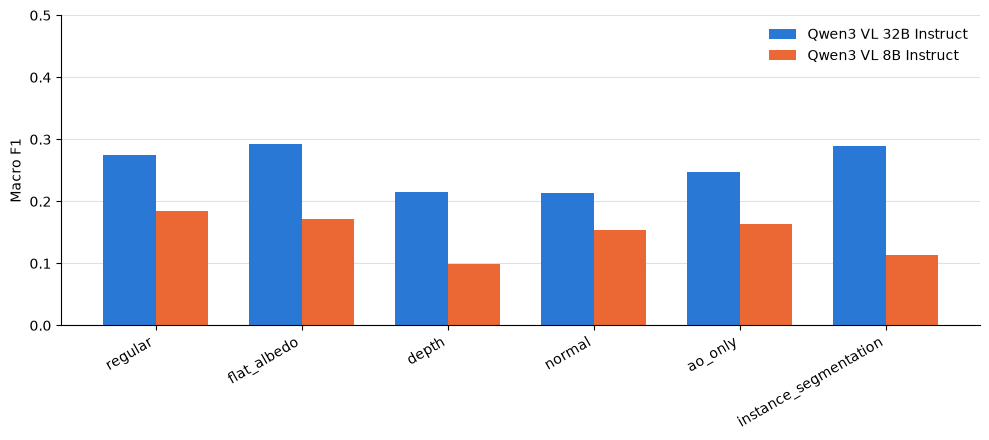

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))

model_to_label = {
    "qwen32_instruct" : "Qwen3 VL 32B Instruct",
    "qwen8_instruct" : "Qwen3 VL 8B Instruct",
}

x = np.arange(len(PASS_ORDER))
bar_width = 0.36

for i, model in enumerate(MODEL_ORDER):
    values = summary.xs(model, level="model").reindex(PASS_ORDER)["macro_f1"]
    offset = (i - 0.5) * bar_width
    ax.bar(x + offset, values, width=bar_width, color=MODEL_COLOR[model], label=model_to_label[model])

ax.set_xticks(x)
ax.set_xticklabels(PASS_ORDER, rotation=30, ha="right")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, max(0.5, summary["macro_f1"].max() * 1.15))
# ax.set_title("Macro-F1 by render pass")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("lighting_independent.png", dpi=300)

## F1 by class x render pass

Where the macro-F1 summary above comes from -- which specific perturbation types drive it, per pass. Same color scale on both panels so the two models are directly comparable.

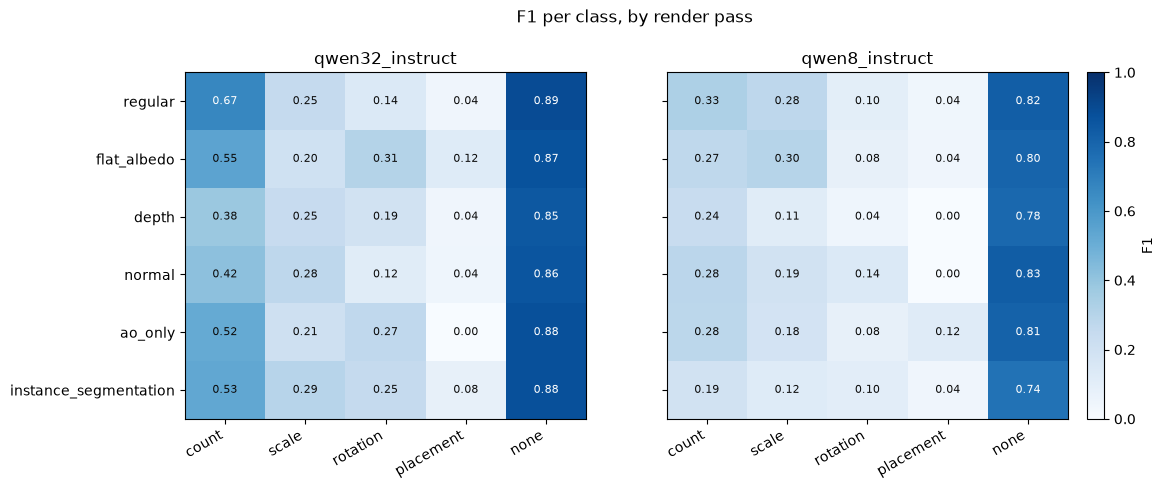

In [6]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(6 * len(MODEL_ORDER), 4.5), sharey=True)

im = None
for ax, model in zip(axes, MODEL_ORDER):
    pivot = (
        all_metrics[all_metrics["model"] == model]
        .pivot(index="pass", columns="class", values="f1")
        .reindex(index=PASS_ORDER, columns=CLASS_ORDER)
    )
    im = ax.imshow(pivot.values, cmap=SEQUENTIAL_CMAP, vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
    ax.set_yticks(range(len(PASS_ORDER)))
    ax.set_yticklabels(PASS_ORDER)
    ax.set_title(model)

    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            value = pivot.values[r, c]
            if np.isnan(value):
                continue
            text_color = "white" if value > 0.6 else "#0b0b0b"
            ax.text(c, r, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

fig.colorbar(im, ax=axes, label="F1", fraction=0.03, pad=0.02)
fig.suptitle("F1 per class, by render pass", y=1.02)
plt.show()

## Which passes help or hurt, relative to regular

F1 delta vs. the `regular` pass for the same class/model: blue = that pass detects the perturbation better than the full-color render; orange = worse.

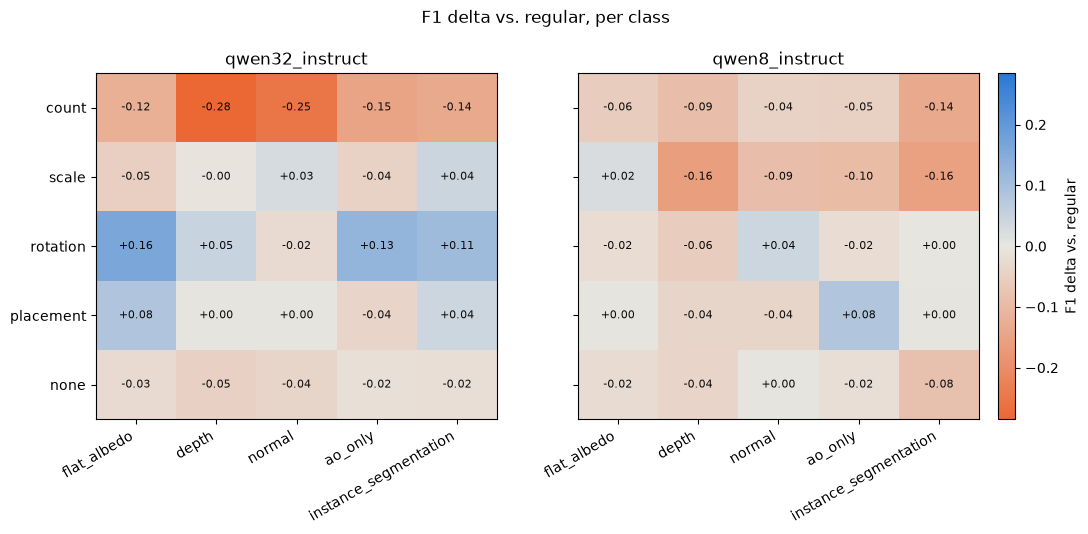

In [7]:
f1_wide = all_metrics.pivot_table(index=["model", "class"], columns="pass", values="f1", observed=True)
non_regular_passes = [p for p in PASS_ORDER if p != "regular"]
delta = f1_wide.sub(f1_wide["regular"], axis=0)[non_regular_passes]

vmax = np.nanmax(np.abs(delta.values))

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(6 * len(MODEL_ORDER), 4.5), sharey=True)

im = None
for ax, model in zip(axes, MODEL_ORDER):
    pivot = delta.loc[model].reindex(CLASS_ORDER)
    im = ax.imshow(pivot.values, cmap=DIVERGING_CMAP, vmin=-vmax, vmax=vmax, aspect="auto")

    ax.set_xticks(range(len(non_regular_passes)))
    ax.set_xticklabels(non_regular_passes, rotation=30, ha="right")
    ax.set_yticks(range(len(CLASS_ORDER)))
    ax.set_yticklabels(CLASS_ORDER)
    ax.set_title(model)

    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            value = pivot.values[r, c]
            if np.isnan(value):
                continue
            ax.text(c, r, f"{value:+.2f}", ha="center", va="center", color="#0b0b0b", fontsize=8)

fig.colorbar(im, ax=axes, label="F1 delta vs. regular", fraction=0.03, pad=0.02)
fig.suptitle("F1 delta vs. regular, per class", y=1.02)
plt.show()

## Confusion matrix

What each model actually predicts vs. the true label (rows sum to 100%). Defaults to `regular`; call `show_confusion` again with any other pass from `PASS_ORDER` to drill in.

In [8]:
def show_confusion(render_pass: str = "regular") -> None:
    pass_predictions = all_predictions[all_predictions["pass"] == render_pass]
    for model in MODEL_ORDER:
        group = pass_predictions[pass_predictions["model"] == model]
        confusion = pd.crosstab(group["true_type"], group["predicted_type"], normalize="index").mul(100).round(1)
        confusion = confusion.reindex(index=CLASS_ORDER, columns=CLASS_ORDER)
        print(f"--- {render_pass} / {model} ---")
        display(confusion)


show_confusion("regular")

--- regular / qwen32_instruct ---


predicted_type,count,scale,rotation,placement,none
true_type,,,,,
count,74.4,2.6,0.0,0.0,23.1
scale,2.5,20.0,15.0,5.0,57.5
rotation,12.8,12.8,10.3,7.7,56.4
placement,12.8,10.3,2.6,2.6,71.8
none,1.7,1.2,1.4,1.2,94.4


--- regular / qwen8_instruct ---


predicted_type,count,scale,rotation,placement,none
true_type,,,,,
count,61.5,0.0,5.1,0.0,33.3
scale,7.5,22.5,5.0,10.0,55.0
rotation,23.1,7.7,7.7,10.3,51.3
placement,28.2,10.3,0.0,2.6,59.0
none,12.7,1.9,2.9,1.2,81.3
